In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
from scipy import linalg

**CIFAR-10 DataLoader**

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [5]:
train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)

100%|███████████████████████████████████████████████████████████████████████████████| 170M/170M [01:23<00:00, 2.04MB/s]


In [6]:
os.makedirs("outputs", exist_ok=True)

**VARIATIONAL AUTOENCODER (VAE) MODEL**

In [8]:
class VAE(nn.Module):
  """Creating the VAE model"""
  def __init__(self, latent_dim=128):
    super(VAE, self).__init__()
    self.latent_dim = latent_dim

    # Encoder
    self.encoder_conv = nn.Sequential(
        nn.Conv2d(3, 32, 4, 2, 1),
        nn.ReLU(),
        nn.Conv2d(32, 64, 4, 2, 1),
        nn.ReLU(),
        nn.Conv2d(64, 128, 4, 2, 1),
        nn.ReLU()
    )
    self.fc_mu = nn.Linear(128 * 4 * 4, latent_dim)
    self.fc_logvar = nn.Linear(128 * 4 * 4, latent_dim)

    # Decoder
    self.decoder_fc = nn.Linear(latent_dim, 128 * 4 * 4)
    self.decoder_conv = nn.Sequential(
        nn.ConvTranspose2d(128, 64, 4, 2, 1),
        nn.ReLU(),
        nn.ConvTranspose2d(64, 32, 4, 2, 1),
        nn.ReLU(),
        nn.ConvTranspose2d(32, 3, 4, 2, 1),
        nn.Tanh()
    )

  def encode(self, x):
    h = self.encoder_conv(x)
    h = h.view(h.size(0), -1)
    return self.fc_mu(h), self.fc_logvar(h)

  def reparameterize(self, mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

  def decode(self, z):
    h = self.decoder_fc(z).view(-1, 128, 4, 4)
    return self.decoder_conv(h)

  def forward(self, x):
    mu, logvar = self.encode(x)
    z = self.reparameterize(mu, logvar)
    return self.decode(z), mu, logvar

**VAE Loss Function**

In [10]:
def vae_loss(x_recon, x, mu, logvar):
  recon_loss = F.mse_loss(x_recon, x, reduction='sum')
  kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
  return recon_loss + kl_div

**DEEP CONVOLUTIONAL GENERATIVE ADVERSARIAL NETWORK (DCGAN) MODEL**

In [12]:
class Generator(nn.Module):
  """The Generator Class for the GAN"""
  def __init__(self, z_dim=100):
    super(Generator, self).__init__()
    self.net = nn.Sequential(
        nn.ConvTranspose2d(z_dim, 512, 4, 1, 0),
        nn.BatchNorm2d(512),
        nn.ReLU(True),
        nn.ConvTranspose2d(512, 256, 4, 2, 1),
        nn.BatchNorm2d(256),
        nn.ReLU(True),
        nn.ConvTranspose2d(256, 128, 4, 2, 1),
        nn.BatchNorm2d(128),
        nn.ReLU(True),
        nn.ConvTranspose2d(128, 3, 4, 2, 1),
        nn.Tanh()
    )

  def forward(self, z):
    return self.net(z)

In [13]:
class Discriminator(nn.Module):
  """The Discriminator Class for the GAN"""
  def __init__(self):
    super(Discriminator, self).__init__()
    self.net = nn.Sequential(
        nn.Conv2d(3, 128, 4, 2, 1),
        nn.LeakyReLU(0.2, inplace=True),
        nn.Conv2d(128, 256, 4, 2, 1),
        nn.BatchNorm2d(256),
        nn.LeakyReLU(0.2, inplace=True),
        nn.Conv2d(256, 512, 4, 2, 1),
        nn.BatchNorm2d(512),
        nn.LeakyReLU(0.2, inplace=True),
        nn.Conv2d(512, 1, 4, 1, 0),
        nn.Sigmoid()
    )

  def forward(self, x):
    return self.net(x).view(-1, 1)

**BETA VAE MODEL**

In [15]:
class BetaVAE(nn.Module):
  def __init__(self, latent_dim=128):
    super(BetaVAE, self).__init__()
    self.latent_dim = latent_dim

    self.encoder_conv = nn.Sequential(
        nn.Conv2d(3, 32, 4, 2, 1), nn.ReLU(),
        nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
        nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU()
    )
    self.fc_mu = nn.Linear(128 * 4 * 4, latent_dim)
    self.fc_logvar = nn.Linear(128 * 4 * 4, latent_dim)

    self.decoder_fc = nn.Linear(latent_dim, 128 * 4 * 4)
    self.decoder_conv = nn.Sequential(
        nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
        nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
        nn.ConvTranspose2d(32, 3, 4, 2, 1), nn.Tanh()
    )

  def encode(self, x):
    h = self.encoder_conv(x).view(x.size(0), -1)
    return self.fc_mu(h), self.fc_logvar(h)

  def reparameterize(self, mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

  def decode(self, z):
    h = self.decoder_fc(z).view(-1, 128, 4, 4)
    return self.decoder_conv(h)

  def forward(self, x):
    mu, logvar = self.encode(x)
    z = self.reparameterize(mu, logvar)
    return self.decode(z), mu, logvar


**BETA VAE Loss Function**

In [17]:
def beta_vae_loss(x_recon, x, mu, logvar, beta=4.0):
  recon_loss = F.mse_loss(x_recon, x, reduction='sum')
  kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
  return recon_loss + beta * kl_div


**VISUALIZE INTERPOLATION IN LATENT SPACE BETWEEN TWO IMAGES**

In [19]:
def visualize_latent_interpolation(model, dataloader, steps=10, filename="latent_interpolation.png"):
  model.eval()
  imgs, _ = next(iter(dataloader))
  img1, img2 = imgs[0].unsqueeze(0).to(device), imgs[1].unsqueeze(0).to(device)
  with torch.no_grad():
    mu1, _ = model.encode(img1)
    mu2, _ = model.encode(img2)
    z_interp = torch.stack([mu1 * (1 - t) + mu2 * t for t in torch.linspace(0, 1, steps)]).squeeze(1)
    recon = model.decode(z_interp)
    save_images(recon, f"outputs/{filename}", nrow=steps)

**SWEEP ACROSS MULTIPLE BETA VALUES**

In [21]:
def beta_sweep_and_visualize(betas=[1, 2, 4, 10], latent_dim=128, steps=10):
  for beta in betas:
    model = BetaVAE(latent_dim=latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    # Train for a few epochs for visualization
    for epoch in range(5):
      model.train()
      for imgs, _ in train_loader:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(imgs)
        loss = beta_vae_loss(recon, imgs, mu, logvar, beta=beta)
        loss.backward()
        optimizer.step()
        break
    visualize_latent_interpolation(model, train_loader, steps, filename=f"latent_beta{beta}.png")
    print(f"Saved latent interpolation for beta={beta}")

**WGAN-GP MODEL**

In [23]:
class WGAN_Generator(nn.Module):
  def __init__(self, z_dim=100):
    super(WGAN_Generator, self).__init__()
    self.net = nn.Sequential(
        nn.ConvTranspose2d(z_dim, 512, 4, 1, 0), nn.GroupNorm(32, 512), nn.ReLU(True),
        nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.GroupNorm(32, 256), nn.ReLU(True),
        nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.GroupNorm(32, 128), nn.ReLU(True),
        nn.ConvTranspose2d(128, 3, 4, 2, 1), nn.Tanh()
    )

  def forward(self, z):
    return self.net(z)

In [24]:
class WGAN_Discriminator(nn.Module):
  def __init__(self):
    super(WGAN_Discriminator, self).__init__()
    self.net = nn.Sequential(
        nn.Conv2d(3, 128, 4, 2, 1), nn.LeakyReLU(0.2),
        nn.Conv2d(128, 256, 4, 2, 1), nn.GroupNorm(32, 256), nn.LeakyReLU(0.2),
        nn.Conv2d(256, 512, 4, 2, 1), nn.GroupNorm(32, 512), nn.LeakyReLU(0.2),
        nn.Conv2d(512, 1, 4, 1, 0)

    )

  def forward(self, x):
    return self.net(x).view(-1)

In [25]:
def gradient_penalty(D, real, fake):
  batch_size = real.size(0)

  alpha = torch.rand(batch_size, 1, 1, 1, device=device)
  interpolated = alpha * real + (1 - alpha) * fake
  interpolated.requires_grad_(True)

  d_interpolated = D(interpolated)
  gradients = torch.autograd.grad(
      outputs=d_interpolated,
      inputs=interpolated,
      grad_outputs=torch.ones_like(d_interpolated),
      create_graph=True,
      retain_graph=True,
      only_inputs=True
  )[0]

  gradients = gradients.view(batch_size, -1)
  penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
  return penalty

**FID Score Evaluation**

In [27]:
def calculate_fid(model, real_loader, fake_generator, num_images=1000, z_dim=100):
  model.eval()
  inception = models.inception_v3(pretrained=True, transform_input=False).to(device)
  inception.fc = nn.Identity()
  inception.eval()

  def get_activations(images):
    images = F.interpolate(images, size=(299, 299), mode='bilinear')
    return inception(images).detach().cpu().numpy()

  real_acts, fake_acts = [], []
  with torch.no_grad():
    for imgs, _ in real_loader:
      real_acts.append(get_activations(imgs.to(device)))
      if len(real_acts) * imgs.size(0) >= num_images:
        break

    for _ in range(num_images // 64):
      noise = torch.randn(64, z_dim, 1, 1, device=device)
      fakes = fake_generator(noise)
      fake_acts.append(get_activations(fakes))

  real_acts = np.concatenate(real_acts, axis=0)
  fake_acts = np.concatenate(fake_acts, axis=0)

  mu1, sigma1 = real_acts.mean(0), np.cov(real_acts, rowvar=False)
  mu2, sigma2 = fake_acts.mean(0), np.cov(fake_acts, rowvar=False)

  diff = mu1 - mu2
  covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
  if np.iscomplexobj(covmean):
    covmean = covmean.real

  fid = diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)
  print(f"FID Score: {fid:.2f}")
  return fid


**Training Utilities**

In [29]:
def save_images(tensor, filename, nrow=8):
  """Visualizing and saving images"""
  grid = make_grid(tensor, nrow=nrow, normalize=True)
  plt.figure(figsize=(8, 8), dpi=200)
  plt.axis('off')
  plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
  plt.savefig(filename)
  plt.close()

**Defining Training Loops**

In [31]:
def train_vae(model, dataloader, optimizer, epochs=10):
  model.train()
  for epoch in range(epochs):
    total_loss = 0
    for imgs, _ in dataloader:
      imgs = imgs.to(device)
      optimizer.zero_grad()
      recon, mu, logvar = model(imgs)
      loss = vae_loss(recon, imgs, mu, logvar)
      loss.backward()
      optimizer.step()
      total_loss += loss.item()

    print(f"[VAE] Epoch {epoch+1}, Loss: {total_loss/len(dataloader.dataset):.4f}")
    with torch.no_grad():
      samples, _, _ = model(next(iter(dataloader))[0].to(device)[:64])
      save_images(samples, f"outputs/vae_epoch{epoch+1}.png")

In [32]:
def train_beta_vae(model, dataloader, optimizer, epochs=10):
  model.train()
  for epoch in range(epochs):
    total_loss = 0
    for imgs, _ in dataloader:
      imgs = imgs.to(device)
      optimizer.zero_grad()
      recon, mu, logvar = model(imgs)
      loss = beta_vae_loss(recon, imgs, mu, logvar)
      loss.backward()
      optimizer.step()
      total_loss += loss.item()

    print(f"[BETA VAE] Epoch {epoch+1}, Loss: {total_loss/len(dataloader.dataset):.4f}")
    with torch.no_grad():
      samples, _, _ = model(next(iter(dataloader))[0].to(device)[:64])
      save_images(samples, f"outputs/vae_epoch{epoch+1}.png")

In [33]:
def train_gan(generator, discriminator, dataloader, g_optimizer, d_optimizer, z_dim=100, epochs=10):
  criterion = nn.BCELoss()
  fixed_noise = torch.randn(64, z_dim, 1, 1, device=device)
  for epoch in range(epochs):
    for imgs, _ in dataloader:
      real = imgs.to(device)
      b_size = real.size(0)
      real_labels = torch.ones(b_size, 1, device=device)
      fake_labels = torch.zeros(b_size, 1, device=device)

      # Train Discriminator
      noise = torch.randn(b_size, z_dim, 1, 1, device=device)
      fake = generator(noise)
      d_real = discriminator(real)
      d_fake = discriminator(fake.detach())
      d_loss = criterion(d_real, real_labels) + criterion(d_fake, fake_labels)

      d_optimizer.zero_grad()
      d_loss.backward()
      d_optimizer.step()


      # Train Generator
      g_loss = criterion(discriminator(fake), real_labels)

      g_optimizer.zero_grad()
      g_loss.backward()
      g_optimizer.step()

    print(f"[GAN] Epoch {epoch+1}, D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")
    with torch.no_grad():
      fake = generator(fixed_noise)
      save_images(fake, f"outputs/gan_epoch{epoch+1}.png")

In [34]:
def train_wgan(generator, discriminator, dataloader, g_optimizer, d_optimizer, z_dim=100, epochs=10, gp_lambda=10.0):
  for epoch in range(epochs):
    for i, (imgs, _) in enumerate(dataloader):
      real = imgs.to(device)
      b_size = real.size(0)

      # Train Discriminator
      for _ in range(5):
        noise = torch.randn(b_size, z_dim, 1, 1, device=device)
        fake = generator(noise).detach()
        d_real = discriminator(real).mean()
        d_fake = discriminator(fake).mean()
        gp = gradient_penalty(discriminator, real, fake)
        d_loss = -d_real + d_fake + gp_lambda * gp

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

      # Train Generator
      noise = torch.randn(b_size, z_dim, 1, 1, device=device)
      fake = generator(noise)
      g_loss = -discriminator(fake).mean()

      g_optimizer.zero_grad()
      g_loss.backward()
      g_optimizer.step()

    print(f"[WGAN-GP] Epoch {epoch+1}, D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")
    with torch.no_grad():
      fake = generator(torch.randn(64, z_dim, 1, 1, device=device))
      save_images(fake, f"outputs/wgan_epoch{epoch+1}.png")

**Device Setup and Model Initialization**

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae = VAE().to(device)
gen = Generator().to(device)
disc = Discriminator().to(device)
beta_vae = BetaVAE().to(device)
wgen = WGAN_Generator().to(device)
wdisc = WGAN_Discriminator().to(device)


vae_optimizer = torch.optim.Adam(vae.parameters(), lr=0.001)
g_optimizer = torch.optim.Adam(gen.parameters(), lr=0.0002, betas=(0.5, 0.999))
d_optimizer = torch.optim.Adam(disc.parameters(), lr=0.0002, betas=(0.5, 0.999))
beta_vae_optimizer = torch.optim.Adam(beta_vae.parameters(), lr=0.001)
wg_optimizer = torch.optim.Adam(wgen.parameters(), lr=0.0001, betas=(0.5, 0.9))
wd_optimizer = torch.optim.Adam(wdisc.parameters(), lr=0.0001, betas=(0.5, 0.9))

**Training the VAE**

In [38]:
train_vae(vae, train_loader, vae_optimizer, epochs=50)

[VAE] Epoch 1, Loss: 334.5147
[VAE] Epoch 2, Loss: 222.1678
[VAE] Epoch 3, Loss: 205.7231
[VAE] Epoch 4, Loss: 199.4653
[VAE] Epoch 5, Loss: 196.2959
[VAE] Epoch 6, Loss: 193.9770
[VAE] Epoch 7, Loss: 192.4364
[VAE] Epoch 8, Loss: 190.9195
[VAE] Epoch 9, Loss: 189.9114
[VAE] Epoch 10, Loss: 188.9384
[VAE] Epoch 11, Loss: 188.3749
[VAE] Epoch 12, Loss: 187.5911
[VAE] Epoch 13, Loss: 186.8836
[VAE] Epoch 14, Loss: 186.3433
[VAE] Epoch 15, Loss: 185.9788
[VAE] Epoch 16, Loss: 185.5502
[VAE] Epoch 17, Loss: 185.3390
[VAE] Epoch 18, Loss: 184.9548
[VAE] Epoch 19, Loss: 184.5156
[VAE] Epoch 20, Loss: 184.3925
[VAE] Epoch 21, Loss: 184.1741
[VAE] Epoch 22, Loss: 183.9771
[VAE] Epoch 23, Loss: 183.7653
[VAE] Epoch 24, Loss: 183.5437
[VAE] Epoch 25, Loss: 183.3682
[VAE] Epoch 26, Loss: 183.1799
[VAE] Epoch 27, Loss: 182.9282
[VAE] Epoch 28, Loss: 182.9624
[VAE] Epoch 29, Loss: 182.6778
[VAE] Epoch 30, Loss: 182.6554
[VAE] Epoch 31, Loss: 182.4480
[VAE] Epoch 32, Loss: 182.4407
[VAE] Epoch 33, L

**Training GAN**

In [40]:
train_gan(gen, disc, train_loader, g_optimizer, d_optimizer, epochs=50)

[GAN] Epoch 1, D Loss: 0.3585, G Loss: 2.6637
[GAN] Epoch 2, D Loss: 0.4923, G Loss: 3.5660
[GAN] Epoch 3, D Loss: 1.1387, G Loss: 6.8978
[GAN] Epoch 4, D Loss: 0.0487, G Loss: 6.4939
[GAN] Epoch 5, D Loss: 0.1790, G Loss: 2.6405
[GAN] Epoch 6, D Loss: 0.1074, G Loss: 4.6454
[GAN] Epoch 7, D Loss: 0.0633, G Loss: 4.5437
[GAN] Epoch 8, D Loss: 0.0341, G Loss: 5.1248
[GAN] Epoch 9, D Loss: 0.6377, G Loss: 5.9392
[GAN] Epoch 10, D Loss: 0.1909, G Loss: 4.1104
[GAN] Epoch 11, D Loss: 0.2161, G Loss: 4.3541
[GAN] Epoch 12, D Loss: 0.1196, G Loss: 3.8627
[GAN] Epoch 13, D Loss: 0.0920, G Loss: 5.6617
[GAN] Epoch 14, D Loss: 0.0940, G Loss: 2.9581
[GAN] Epoch 15, D Loss: 0.0697, G Loss: 4.1125
[GAN] Epoch 16, D Loss: 0.6875, G Loss: 5.6982
[GAN] Epoch 17, D Loss: 0.3082, G Loss: 4.3121
[GAN] Epoch 18, D Loss: 0.1447, G Loss: 4.5245
[GAN] Epoch 19, D Loss: 0.1894, G Loss: 3.7678
[GAN] Epoch 20, D Loss: 0.1619, G Loss: 4.3788
[GAN] Epoch 21, D Loss: 0.0216, G Loss: 5.1126
[GAN] Epoch 22, D Loss

**Training BETA VAE**

In [42]:
train_beta_vae(beta_vae, train_loader, beta_vae_optimizer, epochs=50)

[BETA VAE] Epoch 1, Loss: 421.7603
[BETA VAE] Epoch 2, Loss: 325.1430
[BETA VAE] Epoch 3, Loss: 315.0882
[BETA VAE] Epoch 4, Loss: 311.4333
[BETA VAE] Epoch 5, Loss: 308.8774
[BETA VAE] Epoch 6, Loss: 306.2902
[BETA VAE] Epoch 7, Loss: 304.5259
[BETA VAE] Epoch 8, Loss: 302.9434
[BETA VAE] Epoch 9, Loss: 301.9798
[BETA VAE] Epoch 10, Loss: 301.0664
[BETA VAE] Epoch 11, Loss: 300.7182
[BETA VAE] Epoch 12, Loss: 300.0434
[BETA VAE] Epoch 13, Loss: 299.5492
[BETA VAE] Epoch 14, Loss: 298.9236
[BETA VAE] Epoch 15, Loss: 298.4919
[BETA VAE] Epoch 16, Loss: 298.2023
[BETA VAE] Epoch 17, Loss: 297.7851
[BETA VAE] Epoch 18, Loss: 297.6433
[BETA VAE] Epoch 19, Loss: 297.1887
[BETA VAE] Epoch 20, Loss: 296.9007
[BETA VAE] Epoch 21, Loss: 296.8288
[BETA VAE] Epoch 22, Loss: 296.3555
[BETA VAE] Epoch 23, Loss: 296.2153
[BETA VAE] Epoch 24, Loss: 296.2483
[BETA VAE] Epoch 25, Loss: 295.9697
[BETA VAE] Epoch 26, Loss: 295.6097
[BETA VAE] Epoch 27, Loss: 295.8348
[BETA VAE] Epoch 28, Loss: 295.4526
[

**Training WGAN-GP**

In [44]:
train_wgan(wgen, wdisc, train_loader, wg_optimizer, wd_optimizer, epochs=50)

[WGAN-GP] Epoch 1, D Loss: -8.1275, G Loss: 23.3523
[WGAN-GP] Epoch 2, D Loss: -6.4839, G Loss: 10.6295
[WGAN-GP] Epoch 3, D Loss: -6.3172, G Loss: -0.3001
[WGAN-GP] Epoch 4, D Loss: -5.8211, G Loss: -3.7506
[WGAN-GP] Epoch 5, D Loss: -6.1396, G Loss: -9.3107
[WGAN-GP] Epoch 6, D Loss: -5.3429, G Loss: -12.8589
[WGAN-GP] Epoch 7, D Loss: -4.2375, G Loss: -12.5380
[WGAN-GP] Epoch 8, D Loss: -4.4942, G Loss: -14.9870
[WGAN-GP] Epoch 9, D Loss: -5.1999, G Loss: -12.1478
[WGAN-GP] Epoch 10, D Loss: -5.1198, G Loss: -16.6935
[WGAN-GP] Epoch 11, D Loss: -4.3492, G Loss: -13.8682
[WGAN-GP] Epoch 12, D Loss: -4.0751, G Loss: -15.0215
[WGAN-GP] Epoch 13, D Loss: -5.8248, G Loss: -15.9924
[WGAN-GP] Epoch 14, D Loss: -2.4080, G Loss: -17.1830
[WGAN-GP] Epoch 15, D Loss: -4.3847, G Loss: -19.3064
[WGAN-GP] Epoch 16, D Loss: -3.3310, G Loss: -19.6168
[WGAN-GP] Epoch 17, D Loss: -3.3543, G Loss: -20.4892
[WGAN-GP] Epoch 18, D Loss: -5.6057, G Loss: -18.5148
[WGAN-GP] Epoch 19, D Loss: -4.2521, G Los

**VISUALIZING RECONSTRUCTIONS FROM MODELS**

In [122]:
def show_vae_reconstructions(model, dataloader, num_images=8):
    model.eval()
    imgs, _ = next(iter(dataloader))
    imgs = imgs[:num_images].to(device)
    with torch.no_grad():
        recons, _, _ = model(imgs)
    imgs = imgs.cpu()
    recons = recons.cpu()

    fig, axes = plt.subplots(2, num_images, figsize=(15, 4))
    for i in range(num_images):
        axes[0, i].imshow(imgs[i].permute(1, 2, 0) * 0.5 + 0.5)
        axes[0, i].set_title("Original")
        axes[1, i].imshow(recons[i].permute(1, 2, 0) * 0.5 + 0.5)
        axes[1, i].set_title("Reconstructed")
        axes[0, i].axis("off")
        axes[1, i].axis("off")
    plt.suptitle("VAE RECONSTRUCTION")
    plt.tight_layout()
    plt.show()

In [124]:
def show_beta_vae_reconstructions(model, dataloader, num_images=8):
    model.eval()
    imgs, _ = next(iter(dataloader))
    imgs = imgs[:num_images].to(device)
    with torch.no_grad():
        recons, _, _ = model(imgs)
    imgs = imgs.cpu()
    recons = recons.cpu()

    fig, axes = plt.subplots(2, num_images, figsize=(15, 4))
    for i in range(num_images):
        axes[0, i].imshow(imgs[i].permute(1, 2, 0) * 0.5 + 0.5)
        axes[0, i].set_title("Original")
        axes[1, i].imshow(recons[i].permute(1, 2, 0) * 0.5 + 0.5)
        axes[1, i].set_title("Reconstructed")
        axes[0, i].axis("off")
        axes[1, i].axis("off")
    plt.suptitle("β-VAE RECONSTRUCTION")
    plt.tight_layout()
    plt.show()

In [134]:
def show_gan_samples(generator, z_dim=100, num_images=8):
    generator.eval()
    with torch.no_grad():
        z = torch.randn(num_images, z_dim, 1, 1).to(device)
        samples = generator(z).cpu()
    fig, axes = plt.subplots(1, num_images, figsize=(15, 4))
    for i in range(num_images):
        axes[i].imshow(samples[i].permute(1, 2, 0) * 0.5 + 0.5)
        axes[i].axis("off")
    plt.suptitle("GAN / WGAN-GP Samples")
    plt.tight_layout()
    plt.show()

**CALCULATING FID SCORES FOR MODELS**

In [46]:
calculate_fid(vae, train_loader, gen, num_images=1000, z_dim=100)

C:\Users\eyram\anaconda3\envs\NeuralNetworks\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\eyram\anaconda3\envs\NeuralNetworks\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to C:\Users\eyram/.cache\torch\hub\checkpoints\inception_v3_google-0cc3c7bd.pth
100%|███████████████████████████████████████████████████████████████████████████████| 104M/104M [00:31<00:00, 3.49MB/s]


FID Score: 78.23


78.23080882239219

In [47]:
calculate_fid(gen, train_loader, gen, num_images=1000, z_dim=100)

FID Score: 75.52


75.52367369308185

In [48]:
calculate_fid(disc, train_loader, gen, num_images=1000, z_dim=100)

FID Score: 76.62


76.62307855689718

In [49]:
calculate_fid(beta_vae, train_loader, gen, num_images=1000, z_dim=100)

FID Score: 77.62


77.62023410781228

In [50]:
calculate_fid(wgen, train_loader, gen, num_images=1000, z_dim=100)

FID Score: 76.70


76.69721754506202

In [51]:
calculate_fid(wdisc, train_loader, gen, num_images=1000, z_dim=100)

FID Score: 74.91


74.90685792670395

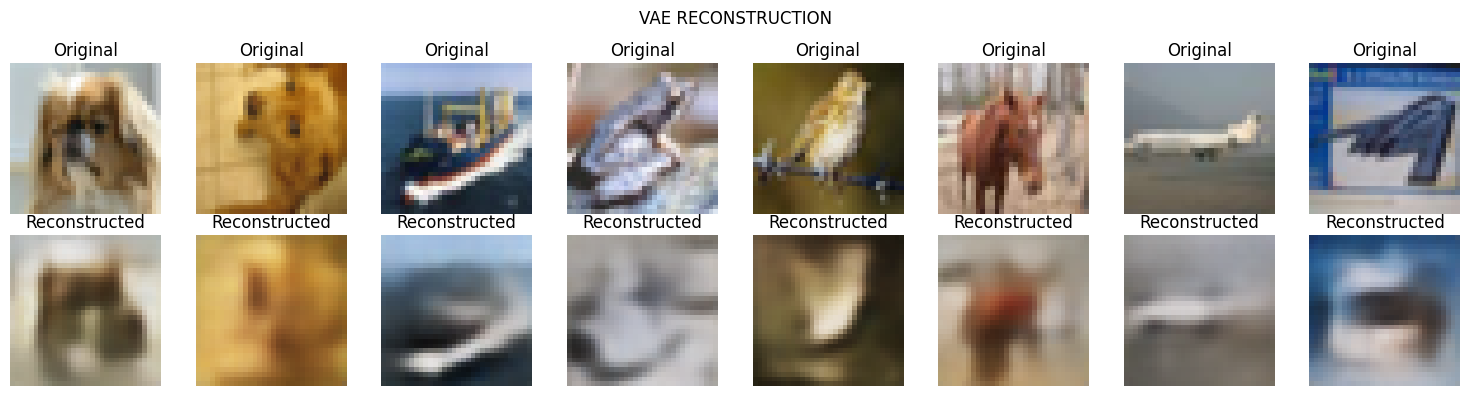

In [128]:
show_vae_reconstructions(vae, train_loader)

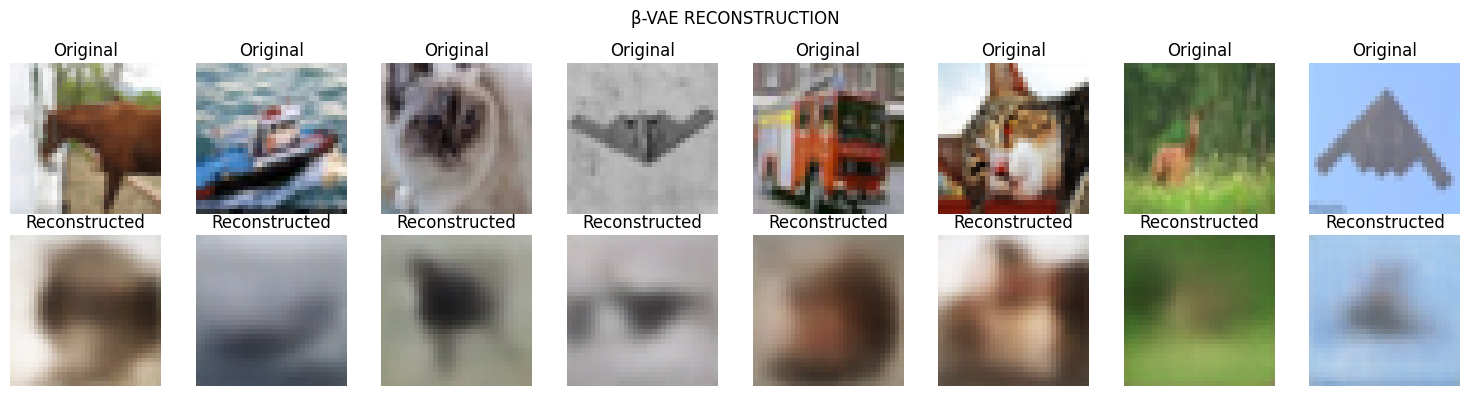

In [130]:
show_beta_vae_reconstructions(beta_vae, train_loader)

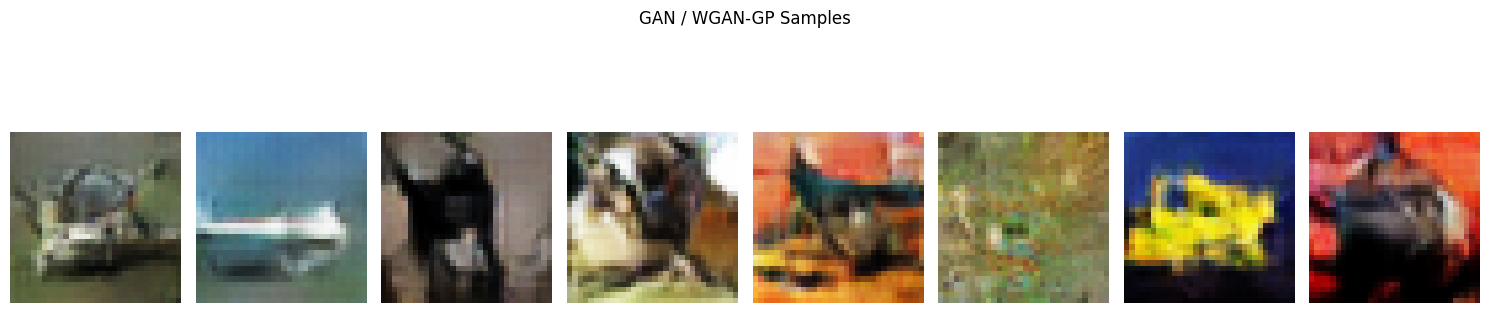

In [136]:
show_gan_samples(gen)

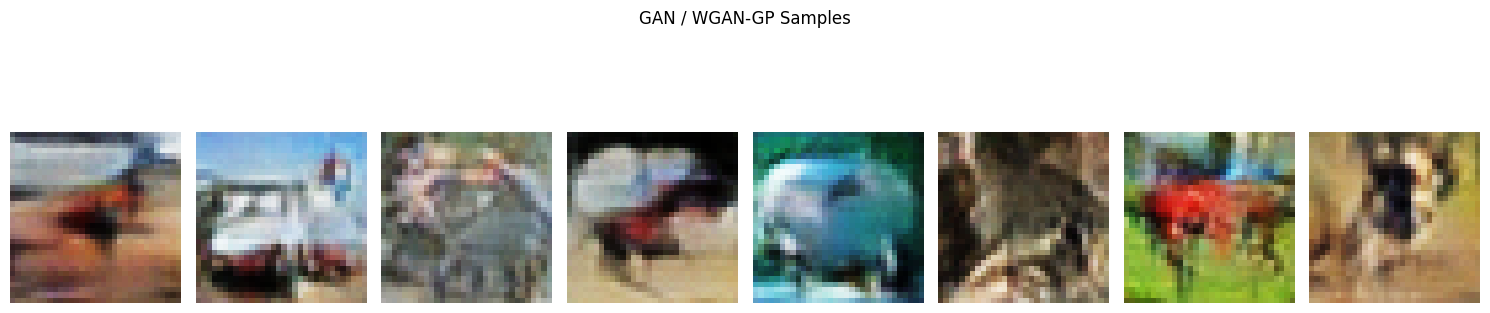

In [138]:
show_gan_samples(wgen)

**VISUALIZING THE LATENT INTERPOLATION BETWEEN TWO IMAGES (FOR VAE & β-VAE)**

In [53]:
visualize_latent_interpolation(vae, train_loader)

In [54]:
visualize_latent_interpolation(beta_vae, train_loader)

**TESTING MULTIPLE BETA VALUES AND VISUALIZING RESULTS**

In [56]:
beta_sweep_and_visualize([1, 2, 4, 10])

Saved latent interpolation for beta=1
Saved latent interpolation for beta=2
Saved latent interpolation for beta=4
Saved latent interpolation for beta=10
